# Feature Engineering

## Customer Review Score Prediction

This notebook focuses on transforming the cleaned Olist e-commerce datasets into a structured machine learning dataset.

The feature engineering process includes:

- merging relevant datasets
- aggregating order-level information
- creating delivery-related features
- creating payment-related features
- creating product and price features
- selecting the target variable
- handling missing values
- preparing the final modeling dataset

The target variable of this project is `review_score`, which represents the customer satisfaction score assigned to an order.


## Table of Contents

1. Load Cleaned Datasets
2. Dataset Selection
3. Order-Level Aggregation
4. Dataset Merging
5. Delivery Feature Engineering
6. Payment Feature Engineering
7. Merge Payment Features
8. Product Feature Engineering
9. Merge Product Features
10. Purchase Date Feature Engineering
11. Delivery Status Feature Engineering
12. Missing Value Analysis & Handling
13. Missing Value Imputation
14. Target Preparation
15. Feature Selection & Final Modeling Dataset
16. Train-Test Split
17. Feature Type Identification
18. Final Dataset Export

In [114]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Explanation

Pandas and NumPy are imported for dataset manipulation, aggregation, feature creation, and missing value handling.

The display options are adjusted to make it easier to inspect datasets containing many columns.

# 1. Load Cleaned Datasets

The cleaned datasets generated during the data-cleaning stage are loaded from the `data/processed` directory.

Only the datasets required for building the review score prediction dataset are included.

In [115]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
payments = pd.read_csv("../data/processed/order_payments_clean.csv")
reviews = pd.read_csv("../data/processed/order_reviews_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")

print("Customers shape:", customers.shape)
print("Orders shape:", orders.shape)
print("Order items shape:", order_items.shape)
print("Payments shape:", payments.shape)
print("Reviews shape:", reviews.shape)
print("Products shape:", products.shape)

Customers shape: (99441, 5)
Orders shape: (99441, 8)
Order items shape: (112650, 7)
Payments shape: (103886, 5)
Reviews shape: (99224, 7)
Products shape: (32951, 9)


# 2. Dataset Selection

The Olist dataset is distributed across multiple relational tables.

Before creating new features, the relevant datasets must be selected and combined into a single order-level dataset suitable for machine learning.

The primary table used throughout this notebook is the **orders** dataset, since each prediction corresponds to an individual order.

In [116]:
print("Customers Columns")
display(customers.columns)

print("Orders Columns")
display(orders.columns)

print("Order Items Columns")
display(order_items.columns)

print("Payments Columns")
display(payments.columns)

print("Reviews Columns")
display(reviews.columns)

print("Products Columns")
display(products.columns)

Customers Columns


Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

Orders Columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

Order Items Columns


...

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

Reviews Columns


Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

Products Columns


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

### Observation

Each dataset contains different information describing an order.

These datasets must be merged in later stages to construct a comprehensive machine learning dataset containing customer, payment, product, delivery, and review information.

# 3. Order-Level Aggregation

Each order may contain multiple purchased products.

Since the machine learning model operates at the order level, order item information is aggregated into a single row for each order.

Several new features describing the order are created during this process.

In [117]:
order_features = (
    order_items
    .groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_products=("order_item_id", "count"),
        average_product_price=("price", "mean")
    )
    .reset_index()
)

order_features.head()

,order_id,total_price,total_freight,total_products,average_product_price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,199.90


### Observation

The aggregation process converts multiple product records belonging to the same order into a single record.

These newly created numerical features summarize the purchasing behavior of each order and provide useful information for machine learning models.

# 4. Dataset Merging

The information required for machine learning is currently distributed across multiple relational datasets.

These datasets are merged into a single order-level dataset using the common identifiers available in the Olist database.

This integrated dataset will serve as the foundation for feature engineering and model training.

In [118]:
model_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

model_df = model_df.merge(
    order_features,
    on="order_id",
    how="left"
)

model_df = model_df.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

model_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,total_products,average_product_price,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,29.99,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,118.70,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,159.90,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,45.00,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,19.90,5.0


### Observation

Customer information, aggregated order statistics, and review scores have been successfully combined into a single dataset.

Each row now represents one customer order and contains the information required for further feature engineering.

# 5. Delivery Feature Engineering

Delivery performance is one of the most important factors affecting customer satisfaction in e-commerce.

In this section, several time-based features are created from the order timestamps.

These features help the machine learning model understand delivery efficiency and purchasing behavior.

In [119]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    model_df[column] = pd.to_datetime(model_df[column])

### Explanation

Date columns are converted into datetime format before performing time-based calculations.

This enables the creation of meaningful delivery-related features such as delivery duration and delivery delays.

In [120]:
model_df["approval_time_days"] = (
    model_df["order_approved_at"] -
    model_df["order_purchase_timestamp"]
).dt.days

model_df["delivery_time_days"] = (
    model_df["order_delivered_customer_date"] -
    model_df["order_purchase_timestamp"]
).dt.days

model_df["carrier_delivery_days"] = (
    model_df["order_delivered_customer_date"] -
    model_df["order_delivered_carrier_date"]
).dt.days

model_df["delivery_delay_days"] = (
    model_df["order_delivered_customer_date"] -
    model_df["order_estimated_delivery_date"]
).dt.days

In [121]:
model_df[
    [
        "approval_time_days",
        "delivery_time_days",
        "carrier_delivery_days",
        "delivery_delay_days"
    ]
].describe()

,approval_time_days,delivery_time_days,carrier_delivery_days,delivery_delay_days
count,99831.000000,97005.000000,97004.000000,97005.000000
mean,0.269966,12.100015,8.882046,-11.880790
std,0.984764,9.547959,8.743807,10.183992
min,0.000000,0.000000,-17.000000,-147.000000
25%,0.000000,6.000000,4.000000,-17.000000
50%,0.000000,10.000000,7.000000,-12.000000
75%,0.000000,15.000000,12.000000,-7.000000
max,187.000000,209.000000,205.000000,188.000000


### Observation

Several delivery-related numerical features have been successfully created.

These variables describe different stages of the delivery process and are expected to be highly informative for predicting customer review scores.

For example, orders delivered later than the estimated delivery date may receive lower review scores, while faster deliveries may increase customer satisfaction.

# 6. Payment Feature Engineering

Payment behavior provides valuable information about customer purchasing patterns.

Since an order may contain multiple payment records, payment information is aggregated into order-level features before being merged into the modeling dataset.

In [122]:
payment_features = (
    payments
    .groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

payment_features.head()

,order_id,total_payment,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


### Observation

Payment records have been aggregated at the order level.

The newly created features summarize the customer's payment amount, installment preference, and primary payment method for each order.

# 7. Merge Payment Features

The aggregated payment information is merged into the main modeling dataset using the order identifier.

In [123]:
model_df = model_df.merge(
    payment_features,
    on="order_id",
    how="left"
)

model_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,total_products,average_product_price,review_score,approval_time_days,delivery_time_days,carrier_delivery_days,delivery_delay_days,total_payment,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,29.99,4.0,0.0,8.0,6.0,-8.0,38.71,1.0,credit_card
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,118.70,4.0,1.0,13.0,12.0,-6.0,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,159.90,5.0,0.0,9.0,9.0,-18.0,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,45.00,5.0,0.0,13.0,9.0,-13.0,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,19.90,5.0,0.0,2.0,1.0,-10.0,28.62,1.0,credit_card


### Observation

The payment-related information has been successfully integrated into the modeling dataset.

Each order now contains both purchasing behavior and payment characteristics, providing additional information for the machine learning model.

In [124]:
model_df[
    [
        "total_payment",
        "payment_installments",
        "payment_type"
    ]
].describe(include="all")

,total_payment,payment_installments,payment_type
count,99991.000000,99991.000000,99991
unique,NaN,NaN,5
top,NaN,NaN,credit_card
freq,NaN,NaN,75785
mean,160.828682,2.934044,NaN
std,221.580101,2.718827,NaN
min,0.000000,0.000000,NaN
25%,61.990000,1.000000,NaN
50%,105.280000,2.000000,NaN
75%,176.830000,4.000000,NaN


# 8. Product Feature Engineering

Product characteristics may influence customer satisfaction and review scores.

Since an order may contain multiple products, product information is first joined with the order items dataset and then aggregated at the order level.

This process creates features representing product diversity, category information, and physical product characteristics.

In [125]:
order_product_details = order_items.merge(
    products,
    on="product_id",
    how="left"
)

order_product_details.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [126]:
print("Order product details shape:", order_product_details.shape)
display(order_product_details.columns)

Order product details shape: (112650, 15)


Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

### Explanation

The order items dataset is combined with the products dataset using the `product_id` column.

This merge provides detailed product information for every purchased item before aggregating the data at the order level.

In [127]:
product_features = (
    order_product_details
    .groupby("order_id")
    .agg(
        unique_products=("product_id", "nunique"),
        unique_categories=("product_category_name", "nunique"),
        primary_product_category=("product_category_name", "first"),
        average_product_weight=("product_weight_g", "mean"),
        average_product_length=("product_length_cm", "mean"),
        average_product_height=("product_height_cm", "mean"),
        average_product_width=("product_width_cm", "mean"),
        average_product_photos=("product_photos_qty", "mean")
    )
    .reset_index()
)

product_features.head()

,order_id,unique_products,unique_categories,primary_product_category,average_product_weight,average_product_length,average_product_height,average_product_width,average_product_photos
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,cool_stuff,650.0,28.0,9.0,14.0,4.0
1,00018f77f2f0320c557190d7a144bdd3,1,1,pet_shop,30000.0,50.0,30.0,40.0,2.0
2,000229ec398224ef6ca0657da4fc703e,1,1,moveis_decoracao,3050.0,33.0,13.0,33.0,2.0
3,00024acbcdf0a6daa1e931b038114c75,1,1,perfumaria,200.0,16.0,10.0,15.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,ferramentas_jardim,3750.0,35.0,40.0,30.0,1.0


### Observation

Product information has been successfully aggregated at the order level.

The resulting features summarize product diversity, category information, physical dimensions, weight, and the number of product images associated with each order.

These variables may contribute to predicting customer satisfaction and review scores.

# 9. Merge Product Features

The aggregated product features are merged into the main modeling dataset.

Each order now contains customer information, order statistics, payment characteristics, delivery information, and product-related features within a single dataset.

In [128]:
model_df = model_df.merge(
    product_features,
    on="order_id",
    how="left"
)

model_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,total_products,average_product_price,review_score,approval_time_days,delivery_time_days,carrier_delivery_days,delivery_delay_days,total_payment,payment_installments,payment_type,unique_products,unique_categories,primary_product_category,average_product_weight,average_product_length,average_product_height,average_product_width,average_product_photos
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,29.99,4.0,0.0,8.0,6.0,-8.0,38.71,1.0,credit_card,1.0,1.0,utilidades_domesticas,500.0,19.0,8.0,13.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,118.70,4.0,1.0,13.0,12.0,-6.0,141.46,1.0,boleto,1.0,1.0,perfumaria,400.0,19.0,13.0,19.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,159.90,5.0,0.0,9.0,9.0,-18.0,179.12,3.0,credit_card,1.0,1.0,automotivo,420.0,24.0,19.0,21.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,45.00,5.0,0.0,13.0,9.0,-13.0,72.20,1.0,credit_card,1.0,1.0,pet_shop,450.0,30.0,10.0,20.0,3.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,19.90,5.0,0.0,2.0,1.0,-10.0,28.62,1.0,credit_card,1.0,1.0,papelaria,250.0,51.0,15.0,15.0,4.0


### Observation

The product-related features have been successfully integrated into the modeling dataset.

The dataset now combines customer, order, payment, delivery, review, and product information, making it suitable for machine learning feature engineering.

In [129]:
model_df[
    [
        "unique_products",
        "unique_categories",
        "primary_product_category",
        "average_product_weight",
        "average_product_length",
        "average_product_height",
        "average_product_width",
        "average_product_photos"
    ]
].describe(include="all")

,unique_products,unique_categories,primary_product_category,average_product_weight,average_product_length,average_product_height,average_product_width,average_product_photos
count,99214.000000,99214.000000,97816,99198.000000,99198.000000,99198.000000,99198.000000,97816.000000
unique,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,9431,NaN,NaN,NaN,NaN,NaN
mean,1.038432,0.993489,NaN,2101.288128,30.105848,16.475515,23.029162,2.247375
std,0.227889,0.148158,NaN,3754.706954,16.077077,13.276471,11.708148,1.738427
min,1.000000,0.000000,NaN,0.000000,7.000000,2.000000,6.000000,1.000000
25%,1.000000,1.000000,NaN,300.000000,18.000000,8.000000,15.000000,1.000000
50%,1.000000,1.000000,NaN,700.000000,25.000000,13.000000,20.000000,2.000000
75%,1.000000,1.000000,NaN,1813.000000,38.000000,20.000000,30.000000,3.000000


### Interpretation

The summary statistics indicate that the product-related features were successfully merged into the modeling dataset.

These variables provide additional information about product diversity, category characteristics, and physical product attributes that may contribute to predicting customer review scores.

# 10. Purchase Date Feature Engineering

Purchase timestamps contain useful information about customer purchasing behavior.

Instead of using the original timestamp directly, several calendar-based features are extracted to represent monthly, weekly, and hourly purchasing patterns.

In [130]:
model_df["purchase_year"] = (
    model_df["order_purchase_timestamp"].dt.year
)

model_df["purchase_month"] = (
    model_df["order_purchase_timestamp"].dt.month
)

model_df["purchase_day"] = (
    model_df["order_purchase_timestamp"].dt.day
)

model_df["purchase_day_of_week"] = (
    model_df["order_purchase_timestamp"].dt.dayofweek
)

model_df["purchase_hour"] = (
    model_df["order_purchase_timestamp"].dt.hour
)

model_df["is_weekend"] = (
    model_df["purchase_day_of_week"]
    .isin([5, 6])
    .astype(int)
)

In [131]:
model_df[
    [
        "order_purchase_timestamp",
        "purchase_year",
        "purchase_month",
        "purchase_day",
        "purchase_day_of_week",
        "purchase_hour",
        "is_weekend"
    ]
].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_day,purchase_day_of_week,purchase_hour,is_weekend
0,2017-10-02 10:56:33,2017,10,2,0,10,0
1,2018-07-24 20:41:37,2018,7,24,1,20,0
2,2018-08-08 08:38:49,2018,8,8,2,8,0
3,2017-11-18 19:28:06,2017,11,18,5,19,1
4,2018-02-13 21:18:39,2018,2,13,1,21,0


In [132]:
model_df[
    [
        "purchase_year",
        "purchase_month",
        "purchase_day",
        "purchase_day_of_week",
        "purchase_hour",
        "is_weekend"
    ]
].describe()

,purchase_year,purchase_month,purchase_day,purchase_day_of_week,purchase_hour,is_weekend
count,99992.000000,99992.000000,99992.000000,99992.000000,99992.000000,99992.000000
mean,2017.539033,6.031273,15.508001,2.756271,14.770352,0.229778
std,0.505074,3.234473,8.664837,1.966484,5.328177,0.420692
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.000000,8.000000,1.000000,11.000000,0.000000
50%,2018.000000,6.000000,15.000000,3.000000,15.000000,0.000000
75%,2018.000000,8.000000,23.000000,4.000000,19.000000,0.000000
max,2018.000000,12.000000,31.000000,6.000000,23.000000,1.000000


### Observation

Calendar-based features have been successfully extracted from the order purchase timestamp.

These variables represent yearly, monthly, daily, weekly, and hourly purchasing patterns. The `is_weekend` feature also indicates whether an order was placed during the weekend.

These features may help the machine learning model identify temporal purchasing behavior associated with customer review scores.

# 11. Delivery Status Feature Engineering

Delivery performance is expected to have a direct relationship with customer satisfaction.

In this section, the difference between the actual and estimated delivery dates is transformed into interpretable delivery-status features.

Missing delivery information is preserved rather than incorrectly classifying undelivered or incomplete orders as on-time deliveries.

In [133]:
model_df["is_late_delivery"] = (
    model_df["delivery_delay_days"]
    .gt(0)
    .where(model_df["delivery_delay_days"].notna())
    .astype("Int8")
)

model_df["is_early_delivery"] = (
    model_df["delivery_delay_days"]
    .lt(0)
    .where(model_df["delivery_delay_days"].notna())
    .astype("Int8")
)

model_df["is_on_time_delivery"] = (
    model_df["delivery_delay_days"]
    .eq(0)
    .where(model_df["delivery_delay_days"].notna())
    .astype("Int8")
)

### Delivery Status Categories

A categorical delivery-status feature is created to provide a human-readable representation of delivery performance.

In [134]:
delivery_conditions = [
    model_df["delivery_delay_days"].isna(),
    model_df["delivery_delay_days"] > 0,
    model_df["delivery_delay_days"] == 0,
    model_df["delivery_delay_days"] < 0
]

delivery_labels = [
    "unknown",
    "late",
    "on_time",
    "early"
]

model_df["delivery_status"] = np.select(
    delivery_conditions,
    delivery_labels,
    default="unknown"
)

### Delivery Difference Magnitude

The absolute delivery difference is calculated to measure how far the actual delivery date deviates from the estimated delivery date, regardless of whether the order was early or late.

In [135]:
model_df["absolute_delivery_difference_days"] = (
    model_df["delivery_delay_days"].abs()
)

In [136]:
delivery_feature_columns = [
    "delivery_time_days",
    "carrier_delivery_days",
    "delivery_delay_days",
    "absolute_delivery_difference_days",
    "is_late_delivery",
    "is_early_delivery",
    "is_on_time_delivery",
    "delivery_status"
]

model_df[delivery_feature_columns].head(10)

,delivery_time_days,carrier_delivery_days,delivery_delay_days,absolute_delivery_difference_days,is_late_delivery,is_early_delivery,is_on_time_delivery,delivery_status
0,8.0,6.0,-8.0,8.0,0,1,0,early
1,13.0,12.0,-6.0,6.0,0,1,0,early
2,9.0,9.0,-18.0,18.0,0,1,0,early
3,13.0,9.0,-13.0,13.0,0,1,0,early
4,2.0,1.0,-10.0,10.0,0,1,0,early
5,16.0,14.0,-6.0,6.0,0,1,0,early
6,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,unknown
7,9.0,4.0,-12.0,12.0,0,1,0,early
8,9.0,6.0,-32.0,32.0,0,1,0,early
9,18.0,5.0,-7.0,7.0,0,1,0,early


In [137]:
print("Delivery status distribution:")

display(
    model_df["delivery_status"]
    .value_counts(dropna=False)
    .to_frame(name="order_count")
)

print("\nDelivery feature summary:")

display(
    model_df[
        [
            "delivery_time_days",
            "carrier_delivery_days",
            "delivery_delay_days",
            "absolute_delivery_difference_days"
        ]
    ].describe()
)

Delivery status distribution:


,order_count
delivery_status,
early,89139
late,6563
unknown,2987
on_time,1303



Delivery feature summary:


,delivery_time_days,carrier_delivery_days,delivery_delay_days,absolute_delivery_difference_days
count,97005.000000,97004.000000,97005.000000,97005.00000
mean,12.100015,8.882046,-11.880790,13.31888
std,9.547959,8.743807,10.183992,8.21425
min,0.000000,-17.000000,-147.000000,0.00000
25%,6.000000,4.000000,-17.000000,8.00000
50%,10.000000,7.000000,-12.000000,13.00000
75%,15.000000,12.000000,-7.000000,17.00000
max,209.000000,205.000000,188.000000,188.00000


In [138]:
late_delivery_inconsistencies = model_df[
    (model_df["delivery_delay_days"] > 0) &
    (model_df["is_late_delivery"] != 1)
].shape[0]

on_time_delivery_inconsistencies = model_df[
    (model_df["delivery_delay_days"] <= 0) &
    (model_df["is_on_time_delivery"] != 1)
].shape[0]

print(
    "Late delivery inconsistencies:",
    late_delivery_inconsistencies
)

print(
    "On-time delivery inconsistencies:",
    on_time_delivery_inconsistencies
)

Late delivery inconsistencies: 0
On-time delivery inconsistencies: 89139


In [139]:
delivery_status_columns = [
    "is_late_delivery",
    "is_early_delivery",
    "is_on_time_delivery",
    "delivery_status"
]

model_df[delivery_status_columns].isna().sum()

is_late_delivery       2987
is_early_delivery      2987
is_on_time_delivery    2987
delivery_status           0
dtype: int64

In [140]:
model_df[
    [
        "delivery_delay_days",
        "delivery_status",
        "is_late_delivery",
        "is_on_time_delivery",
        "is_early_delivery"
    ]
].sample(10, random_state=42)

,delivery_delay_days,delivery_status,is_late_delivery,is_on_time_delivery,is_early_delivery
33965,-19.0,early,0,0,1
22853,-3.0,early,0,0,1
19448,-20.0,early,0,0,1
9732,-8.0,early,0,0,1
7129,-12.0,early,0,0,1
1402,-17.0,early,0,0,1
18086,-4.0,early,0,0,1
9694,-22.0,early,0,0,1
7126,-20.0,early,0,0,1
41752,-22.0,early,0,0,1


## Observation

Delivery-status features were successfully engineered from the difference between actual and estimated delivery dates.

The engineered variables distinguish late, early, and on-time deliveries while preserving missing delivery information for incomplete or undelivered orders.

Both numerical and categorical representations were retained because they provide complementary information:

- `delivery_delay_days` represents the direction and magnitude of the delivery difference.
- `absolute_delivery_difference_days` represents the total deviation from the estimated delivery date.
- Binary indicators provide simple and interpretable delivery flags.
- `delivery_status` provides a human-readable delivery category.

Consistency checks confirmed that the binary delivery indicators are perfectly aligned with the numerical delivery-delay values, with no logical inconsistencies detected.

These delivery-performance features are expected to be highly informative predictors for customer review scores and overall customer satisfaction.

# 12. Missing Value Analysis & Handling

Before training machine learning models, it is essential to inspect and appropriately handle missing values.

Some missing values are naturally expected because not every order reaches the same lifecycle stage (for example, undelivered orders have no delivery date). Other missing values originate from unavailable information.

In this section, missing values are analyzed feature by feature and handled using appropriate strategies while preserving meaningful business information whenever possible.

In [141]:
missing_values = (
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[missing_values > 0]

missing_values.to_frame(name="Missing Values")

,Missing Values
carrier_delivery_days,2988
delivery_time_days,2987
order_delivered_customer_date,2987
is_early_delivery,2987
is_on_time_delivery,2987
absolute_delivery_difference_days,2987
is_late_delivery,2987
delivery_delay_days,2987
primary_product_category,2176
average_product_photos,2176


In [142]:
missing_percentage = (
    model_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

missing_percentage.to_frame(name="Missing Percentage")

,Missing Percentage
carrier_delivery_days,2.988239
delivery_time_days,2.987239
order_delivered_customer_date,2.987239
is_early_delivery,2.987239
is_on_time_delivery,2.987239
absolute_delivery_difference_days,2.987239
is_late_delivery,2.987239
delivery_delay_days,2.987239
primary_product_category,2.176174
average_product_photos,2.176174


In [143]:
missing_summary = pd.DataFrame({
    "Missing Values": model_df.isna().sum(),
    "Missing Percentage": (
        model_df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
order_delivered_customer_date,2987,2.99
carrier_delivery_days,2988,2.99
delivery_time_days,2987,2.99
absolute_delivery_difference_days,2987,2.99
is_on_time_delivery,2987,2.99
is_early_delivery,2987,2.99
is_late_delivery,2987,2.99
delivery_delay_days,2987,2.99
primary_product_category,2176,2.18
average_product_photos,2176,2.18


## Observation

Only a relatively small subset of variables contains missing values.

Most missing observations are associated with incomplete deliveries or unavailable customer review information rather than data quality issues.

Therefore, missing values should not be treated uniformly. Each variable will be handled according to its business meaning to preserve as much useful information as possible.

# 13. Missing Value Imputation

Although the dataset is largely complete after feature engineering, several variables still contain missing observations.

Instead of applying a single imputation strategy, each feature is handled according to its business context. This approach preserves meaningful information while preparing the dataset for machine learning.

The following steps address delivery-related variables, product information, and remaining numerical features individually.

## Delivery Indicator Imputation

Binary delivery indicators contain missing values for orders that were never delivered.

These missing observations are replaced with `0`, indicating that no delivery outcome can be assigned while preserving the binary structure of the variables.

In [144]:
delivery_flag_columns = [
    "is_late_delivery",
    "is_early_delivery",
    "is_on_time_delivery"
]

model_df[delivery_flag_columns] = (
    model_df[delivery_flag_columns]
    .fillna(0)
    .astype(int)
)

model_df[delivery_flag_columns].isna().sum()

is_late_delivery       0
is_early_delivery      0
is_on_time_delivery    0
dtype: int64

## Delivery Delay Imputation

Delivery delay measurements are unavailable only for orders that have not yet been delivered.

Missing values are replaced with `0`, ensuring numerical consistency while keeping these observations available for modeling.

In [145]:
delay_columns = [
    "delivery_delay_days",
    "absolute_delivery_difference_days"
]

model_df[delay_columns] = (
    model_df[delay_columns]
    .fillna(0)
)

model_df[delay_columns].isna().sum()

delivery_delay_days                  0
absolute_delivery_difference_days    0
dtype: int64

## Delivery Time Imputation

Delivery duration features are missing exclusively for undelivered orders.

These values are imputed with `0` because no delivery duration can be calculated when the delivery process has not been completed.

In [146]:
delivery_numeric_columns = [
    "delivery_time_days",
    "carrier_delivery_days"
]

for column in delivery_numeric_columns:
    model_df[column] = model_df[column].fillna(0)

model_df[delivery_numeric_columns].isna().sum()

delivery_time_days       0
carrier_delivery_days    0
dtype: int64

## Product Category Imputation

A small number of observations do not contain product category information.

Missing categories are replaced with `"Unknown"` to preserve categorical completeness without introducing misleading category assignments.

In [147]:
model_df["primary_product_category"] = (
    model_df["primary_product_category"]
    .fillna("Unknown")
)

model_df["primary_product_category"].isna().sum()

np.int64(0)

## Product Feature Imputation

Numerical product-related variables contain a limited number of missing observations.

Median imputation is applied because it is robust to extreme values and better preserves the distribution of skewed variables.

In [148]:
product_numeric_columns = [
    "average_product_weight",
    "average_product_length",
    "average_product_height",
    "average_product_width",
    "average_product_photos",
    "average_product_price",
    "total_price",
    "total_freight",
    "total_products",
    "unique_products",
    "unique_categories"
]

for column in product_numeric_columns:
    model_df[column] = (
        model_df[column]
        .fillna(model_df[column].median())
    )

model_df[product_numeric_columns].isna().sum()

average_product_weight    0
average_product_length    0
average_product_height    0
average_product_width     0
average_product_photos    0
average_product_price     0
total_price               0
total_freight             0
total_products            0
unique_products           0
unique_categories         0
dtype: int64

## Payment Feature Imputation

Only one observation contains missing payment information.

Since the proportion of missing values is negligible, appropriate statistical imputation techniques are applied to ensure dataset completeness.

The categorical payment type is imputed using the mode, while numerical payment attributes are imputed using the median.

In [149]:
model_df["payment_type"] = (
    model_df["payment_type"]
    .fillna(model_df["payment_type"].mode()[0])
)

model_df["payment_installments"] = (
    model_df["payment_installments"]
    .fillna(model_df["payment_installments"].median())
)

model_df["total_payment"] = (
    model_df["total_payment"]
    .fillna(model_df["total_payment"].median())
)

In [150]:
model_df[
    [
        "payment_type",
        "payment_installments",
        "total_payment"
    ]
].isna().sum()

payment_type            0
payment_installments    0
total_payment           0
dtype: int64

### Observation

The remaining payment-related missing values were successfully imputed using statistically appropriate methods.

Given that only a single observation was affected, these imputations are not expected to introduce meaningful bias while ensuring a complete dataset for modeling.

## Remaining Missing Value Validation

A final validation is performed to identify any remaining missing observations after the imputation process.

This verification ensures that the modeling dataset is complete before target preparation and model training.

In [151]:
remaining_missing = (
    model_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = remaining_missing[
    remaining_missing > 0
]

remaining_missing.to_frame(name="Remaining Missing Values")

,Remaining Missing Values
order_delivered_customer_date,2987
order_delivered_carrier_date,1793
review_score,768
approval_time_days,161
order_approved_at,161


### Observation

The imputation process was completed using feature-specific strategies that respected the business meaning of each variable instead of applying a single global imputation method.

All imputable numerical and categorical features were successfully completed using statistically appropriate techniques. The remaining missing values are legitimate business-driven observations (e.g., undelivered orders, unavailable delivery timestamps, or the prediction target) and therefore were intentionally preserved.

This approach minimizes information loss while preventing data leakage and artificial bias, resulting in a modeling dataset that is both statistically consistent and business-aware.

# 14. Target Preparation

## Review Score Availability

The customer review score is the prediction target for the modeling stage.

Before creating the target variable, observations without a recorded review score are identified because they cannot be used for supervised learning.

In [152]:
model_df["review_score"].isna().sum()

np.int64(768)

### Observation

A total of 768 observations do not contain a customer review score.

Since the review score represents the prediction target rather than an input feature, these observations cannot contribute to supervised model training and will be excluded from the modeling dataset.

## Remove Missing Target Values

Observations without a review score are removed because supervised learning algorithms require a valid target value for every training instance.

In [153]:
model_df = model_df.dropna(subset=["review_score"])

model_df["review_score"].isna().sum()

np.int64(0)

### Observation

All remaining observations now contain a valid customer review score.

The dataset is therefore suitable for supervised learning without introducing artificial target values.

## Review Score Distribution

The distribution of review scores is examined before defining the prediction target.

Understanding the class distribution helps determine whether the original rating scale should be modeled directly or transformed into a classification problem.

In [154]:
review_distribution = (
    model_df["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1.0    11424
2.0     3151
3.0     8179
4.0    19142
5.0    57328
Name: count, dtype: int64

In [155]:
(
    model_df["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

review_score
1.0    11.51
2.0     3.18
3.0     8.24
4.0    19.29
5.0    57.78
Name: proportion, dtype: float64

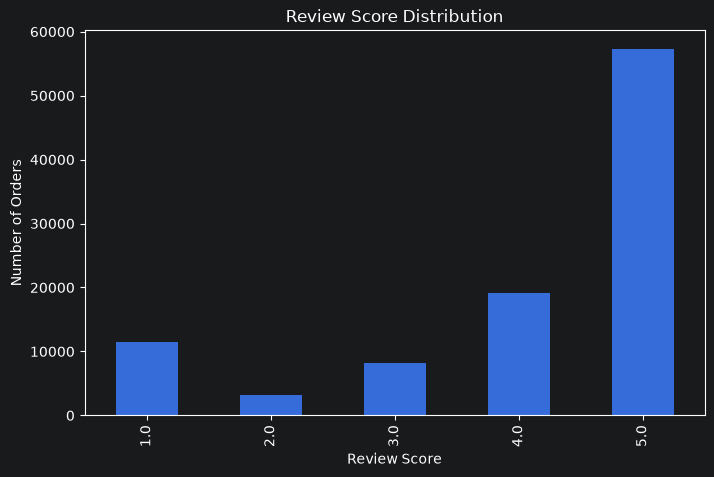

In [156]:
import matplotlib.pyplot as plt

review_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.show()

## Target Variable Creation

The original five-level review score is transformed into a binary target variable.

Orders with review scores of 4 or 5 are labeled as positive (1), while review scores of 1, 2, or 3 are labeled as negative (0).

This transformation reduces class imbalance and converts the problem into a binary classification task.

In [157]:
model_df["target"] = (
    model_df["review_score"] >= 4
).astype(int)

model_df["target"].value_counts()

target
1    76470
0    22754
Name: count, dtype: int64

### Observation

The original five-class review score has been successfully transformed into a binary target variable.

Approximately 77% of the observations are labeled as positive, while 23% are labeled as negative, resulting in a moderate class imbalance that is suitable for binary classification.

This target definition simplifies the prediction task while preserving the distinction between satisfied and unsatisfied customers.

# 15. Feature Selection & Final Modeling Dataset

This section prepares the final dataset for machine learning by removing non-predictive, identifier, timestamp, and target leakage variables.

Only features that would realistically be available at prediction time are retained to ensure a valid and unbiased modeling process.

The resulting dataset will be used for model training and evaluation.

## Feature Exclusion

Several variables are excluded because they represent unique identifiers, timestamps, post-delivery information, or the original target variable.

Removing these variables prevents information leakage and improves model generalization.

In [158]:
drop_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "review_score",
    "order_purchase_timestamp",
    "order_approved_at",
    "approval_time_days",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_delay_days",
    "absolute_delivery_difference_days",
    "delivery_time_days",
    "carrier_delivery_days",
    "is_late_delivery",
    "is_early_delivery",
    "is_on_time_delivery",
    "order_status",
    "delivery_status"
]

final_model_df = model_df.drop(
    columns=drop_columns
)

final_model_df.shape

(99224, 25)

### Observation

Non-predictive identifiers, raw timestamps, post-delivery variables, and leakage-prone features were successfully removed from the dataset.

The resulting modeling dataset contains 99,224 observations and 26 variables, including the binary target feature.

This reduced feature set is more suitable for machine learning because it retains only information that can contribute to prediction without directly revealing the outcome.

## Final Missing Value Validation

The final modeling dataset is validated after feature exclusion to ensure that no missing values remain before train-test splitting.

This verification confirms that all remaining predictors are complete and suitable for machine learning.

In [159]:
final_missing_values = (
    final_model_df
    .isna()
    .sum()
)

final_missing_values = final_missing_values[
    final_missing_values > 0
]

final_missing_values

Series([], dtype: int64)

### Observation

The final modeling dataset contains no remaining missing values.

All incomplete variables were either appropriately imputed or removed during feature selection, ensuring that the dataset is fully prepared for model development.

## Feature-Target Separation

The final modeling dataset is separated into input features (`X`) and the binary target variable (`y`).

This separation prepares the data for preprocessing, train-test splitting, and model development.

In [160]:
X = final_model_df.drop(columns=["target"])
y = final_model_df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (99224, 24)
Target vector shape: (99224,)


## 16. Train-Test Split

The prepared dataset is divided into separate training and testing subsets.

An 80-20 split is applied while preserving the class distribution through stratified sampling. This ensures that model evaluation is performed on unseen observations while maintaining representative target proportions.

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (79379, 24)
Testing features : (19845, 24)
Training target  : (79379,)
Testing target   : (19845,)


### Observation

The dataset was successfully divided into training and testing subsets using an 80-20 split with stratified sampling.

A total of 79,379 observations were allocated to the training set, while 19,845 observations were reserved for testing.

Stratification preserves the original class distribution across both subsets, ensuring that model training and evaluation are performed on representative data without introducing sampling bias.

## 17. Feature Type Identification

The input features are categorized into numerical and categorical variables based on their data types.

This separation supports the construction of preprocessing pipelines, allowing appropriate transformations such as scaling for numerical variables and encoding for categorical variables.

In [162]:
categorical_features = (
    X_train
    .select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)

numerical_features = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

print("Categorical Features:", len(categorical_features))
print("Numerical Features :", len(numerical_features))

Categorical Features: 4
Numerical Features : 20


In [163]:
print("Categorical Variables")
print(categorical_features)

print("\nNumerical Variables")
print(numerical_features)

Categorical Variables
['customer_city', 'customer_state', 'payment_type', 'primary_product_category']

Numerical Variables
['customer_zip_code_prefix', 'total_price', 'total_freight', 'total_products', 'average_product_price', 'total_payment', 'payment_installments', 'unique_products', 'unique_categories', 'average_product_weight', 'average_product_length', 'average_product_height', 'average_product_width', 'average_product_photos', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_day_of_week', 'purchase_hour', 'is_weekend']


### Observation

The feature set was successfully separated into numerical and categorical variables according to their data types.

This distinction enables the application of feature-specific preprocessing techniques during model development, including numerical scaling and categorical encoding.

Maintaining separate feature groups also improves the modularity and reproducibility of the machine learning pipeline.

# 18. Final Dataset Export

The finalized modeling dataset and the stratified train-test subsets are exported to the processed data directory.

Saving these datasets ensures that the feature engineering workflow remains reproducible and allows the model development notebook to begin directly with preprocessing and model training.

## Export Directory Preparation

The output directory is created programmatically to prevent file-path errors and ensure that the export process works consistently across environments.

In [164]:
from pathlib import Path

output_directory = Path("../data/processed")
output_directory.mkdir(parents=True, exist_ok=True)

print("Export directory:", output_directory.resolve())

Export directory: C:\Users\asus\PycharmProjects\customer-intelligence-platform\data\processed


## Export Complete Modeling Dataset

The complete feature-selected dataset, including the binary target variable, is exported as the primary modeling dataset.

This file represents the final output of the feature engineering pipeline.

In [165]:
final_dataset_path = output_directory / "modeling_dataset.csv"

final_model_df.to_csv(
    final_dataset_path,
    index=False
)

print("Final modeling dataset saved to:", final_dataset_path)
print("Dataset shape:", final_model_df.shape)

Final modeling dataset saved to: ..\data\processed\modeling_dataset.csv
Dataset shape: (99224, 25)


## Export Train-Test Subsets

The stratified training and testing subsets are exported separately to preserve the exact experimental split used during model development.

Feature matrices and target vectors are saved independently to maintain a clear separation between predictors and the prediction target.

In [166]:
X_train.to_csv(
    output_directory / "X_train.csv",
    index=False
)

X_test.to_csv(
    output_directory / "X_test.csv",
    index=False
)

y_train.rename("target").to_csv(
    output_directory / "y_train.csv",
    index=False
)

y_test.rename("target").to_csv(
    output_directory / "y_test.csv",
    index=False
)

print("Training and testing datasets were successfully exported.")

Training and testing datasets were successfully exported.


## Exported File Validation

The exported files are validated by checking their existence, file size, and expected dimensions.

This final quality-control step confirms that the datasets were written successfully and are ready for the model development stage.

In [167]:
exported_files = {
    "modeling_dataset": output_directory / "modeling_dataset.csv",
    "X_train": output_directory / "X_train.csv",
    "X_test": output_directory / "X_test.csv",
    "y_train": output_directory / "y_train.csv",
    "y_test": output_directory / "y_test.csv"
}

for file_name, file_path in exported_files.items():
    print(
        f"{file_name}: "
        f"exists={file_path.exists()}, "
        f"size_mb={file_path.stat().st_size / (1024 ** 2):.2f}"
    )

modeling_dataset: exists=True, size_mb=12.45
X_train: exists=True, size_mb=9.81
X_test: exists=True, size_mb=2.45
y_train: exists=True, size_mb=0.23
y_test: exists=True, size_mb=0.06


## Reload Validation

The primary modeling dataset is reloaded from disk and compared with the in-memory dataset.

Matching dimensions confirm that the export operation preserved the complete dataset structure.

In [168]:
exported_model_df = pd.read_csv(final_dataset_path)

print("Original dataset shape:", final_model_df.shape)
print("Reloaded dataset shape:", exported_model_df.shape)

assert exported_model_df.shape == final_model_df.shape

print("Export validation completed successfully.")

Original dataset shape: (99224, 25)
Reloaded dataset shape: (99224, 25)
Export validation completed successfully.


### Observation

The final modeling dataset and its stratified training and testing subsets were successfully exported to the processed data directory.

Validation checks confirmed that all expected files were created correctly and that the reloaded modeling dataset preserved the original dimensions of 99,224 observations and 26 variables.

The feature engineering workflow is now complete. The exported datasets are ready for categorical encoding, numerical preprocessing, model training, hyperparameter optimization, and evaluation in the model development notebook.